## Import libraries

In [1]:
import os
import sys
import pandas as pd
import numpy as np

src_dir = os.path.join(os.getcwd(), "src")
src_parent = os.path.dirname(src_dir)
if src_parent not in sys.path:
    sys.path.insert(0, src_parent)

# from src.data_extraction import extract_and_save
from src.pipeline import process_all_phases

## Plaxis initialization

In [2]:
# from plxscripting.easy import *
# localhostport_input = 10000
# localhostport_output = 10001

# s_i, g_i = new_server('localhost', localhostport_input, password='')
# s_o, g_o = new_server('localhost', localhostport_output, password='')

## Input data

In [3]:
# ---------------- CONFIG ----------------
materials = [
#     'RejeitoCoarseSoft','RejeitoFineSoft','RejeitoMediumSoft',
    'RejeitoCoarseHSSSoft','RejeitoFineHSSSoft','RejeitoMediumHSSSoft', 
    'AterroRejeitoCompactado','AterroCompactado','DrainMaterial','UltrafineIronore'
] # Materiales a considerar en el cálculo del área vulnerable
xmin, xmax = 96, 444 # Ventana vulnerable en X (por ejemplo, si el ΔX = Xcresta - Xpie, usar Xmin = Xpie y Xmax = Xcresta + 0.5 * ΔX )

phases_to_extract = ['Phase_41', 'Phase_59', 'Phase_60', 'Phase_61'] # Fases a extraer de Plaxis
phases_to_plot = ['Phase_41'] # Fases a procesar y graficar
# phases_to_extract = ['Phase_41', 'Phase_1', 'Phase_42'] # Números de fase a extraer
num_nodes_per_elem = 15

# model_name = "MODEL_NAME" # Nombre del modelo, para guardar en carpetas
model_name = "ID-2_HSS0-HSS-Consolidation-RL942-RevC" # Nombre del modelo, para guardar en carpetas
dir_raw = os.path.join("./raw_data_csvs", model_name)

plot_water_table = True  # Cambia a False para no plotear el nivel freático
water_table_label = "Water table"  # Etiqueta para el nivel freático en la leyenda
water_table_colour = "darkblue"  # Color para el nivel freático en la leyenda
# process_method = "all"  # "saturated_area", "hydraulic_energy", "effective_stress_energy", "ru" o "all"
process_method = "ru"  # "saturated_area", "hydraulic_energy", "effective_stress_energy", "ru" o "all"
reference_phase = "Phase_26"  # Fase de referencia para Ru
stress_field = "SigyyE"  # Valor para hydraulic_stress_state / Ru; puede ser "SigyyE" o "MeanEffStress"
phases_to_extract.append(reference_phase)  # Asegura que la fase de referencia también se extraiga

dam_height = None  # Altura manual de presa, o None para usar Ymax-Ymin
gamma_w = 10.0  # Peso específico del agua [kN/m3]
print_debug_info = True  # Activa impresión de debug en resultados

config = {
    "xmin": xmin,
    "xmax": xmax,
    "num_nodes_per_elem": num_nodes_per_elem,
    "grid_resolution": 500,
    "plot_water_table": plot_water_table,
    "water_table_label": water_table_label,
    "water_table_colour": water_table_colour,  # Water table color for plotting
    "process_method": process_method,  # "saturated_area", "hydraulic_energy", "effective_stress_energy", "ru" o "all"
    "reference_phase": reference_phase,  # Reference phase for Ru method
    "stress_field": stress_field,  # "SigyyE" o "MeanEffStress"
    "dam_height": dam_height,
    "gamma_w": gamma_w,
    "print_debug_info": print_debug_info,
    "phases_to_plot": phases_to_plot,
}

outdir_model = os.path.join(os.getcwd(), dir_raw)
outdir_figs = os.path.join(os.getcwd(), "figures")

### Plaxis extract and save (just the first time)

In [4]:
# # Carpeta del modelo dentro de raw_data_csvs
# outdir_model = os.path.join(os.getcwd(), dir_raw)
# os.makedirs(outdir_model, exist_ok=True)

# saved_info = extract_and_save(
#     g_i=g_i,
#     g_o=g_o,
#     phases_to_extract=phases_to_extract,
#     materials=materials,
#     num_nodes_per_elem=num_nodes_per_elem,
#     outdir_model=outdir_model,
# )

### Calculate and plot


[DEBUG] Matching summary:
 current   : 116679
 reference : 168780
 matched   : 116679

[DEBUG] Distance statistics (current vs nearest ref):
 min  : 1.4851261075040804e-11
 mean : 3.809145898254554e-09
 max  : 7.05906130652162e-09

[DEBUG] Sample distance check:
i=88123
 current : [303.10128578 876.80317331]
 nearest : [303.10128578 876.80317331]
 dist    : 2.7441657699469004e-09

i=69193
 current : [404.97745632 879.62658065]
 nearest : [404.97745632 879.62658065]
 dist    : 9.273101077380557e-10

i=107689
 current : [186.45979608 859.05211879]
 nearest : [186.45979608 859.05211879]
 dist    : 4.7240754831111076e-09

i=78041
 current : [326.58296365 884.86495626]
 nearest : [326.58296365 884.86495626]
 dist    : 2.773427408369669e-09

i=20342
 current : [402.27990198 918.71885093]
 nearest : [402.27990198 918.71885093]
 dist    : 5.32556011823081e-09



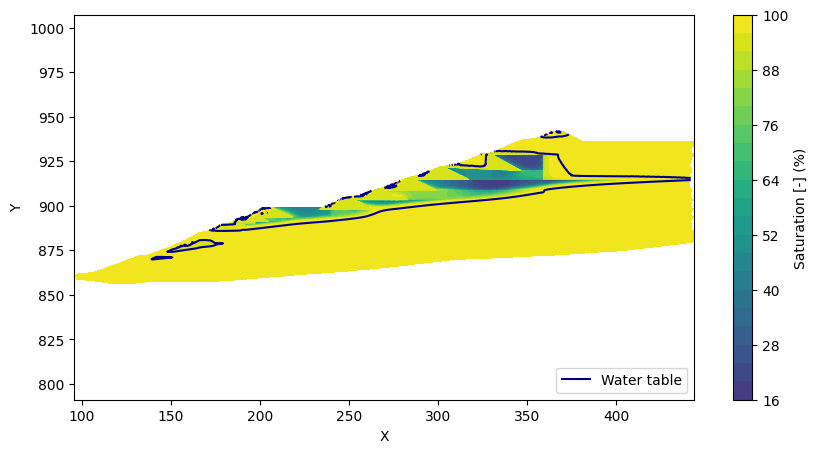

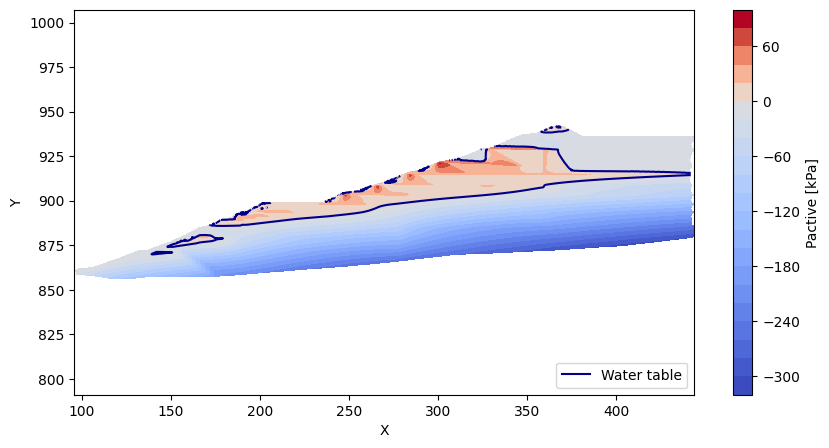

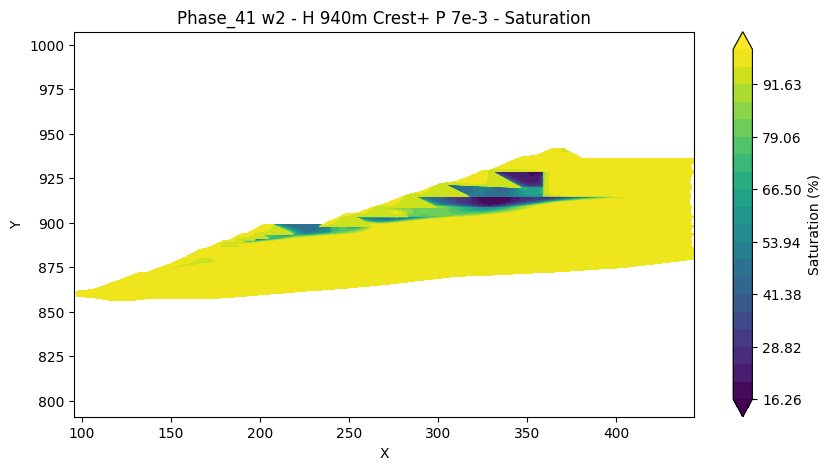

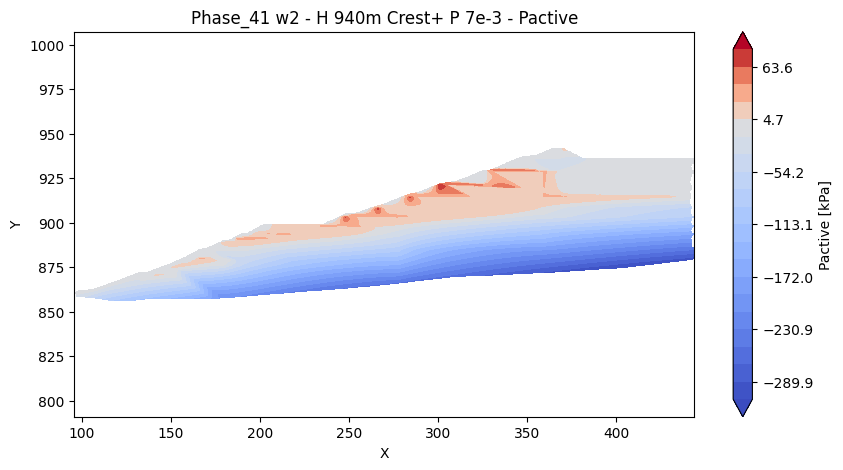

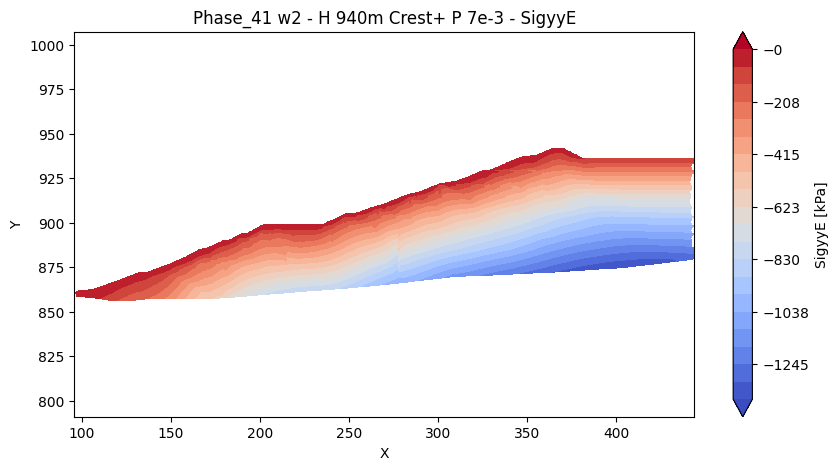

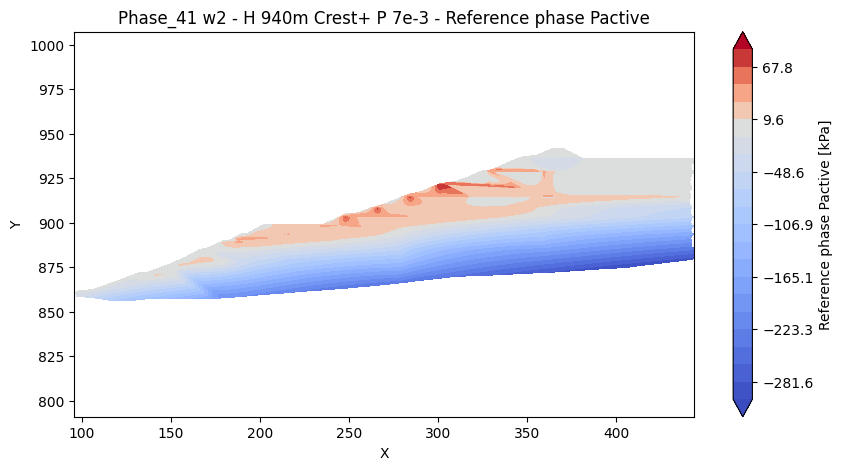

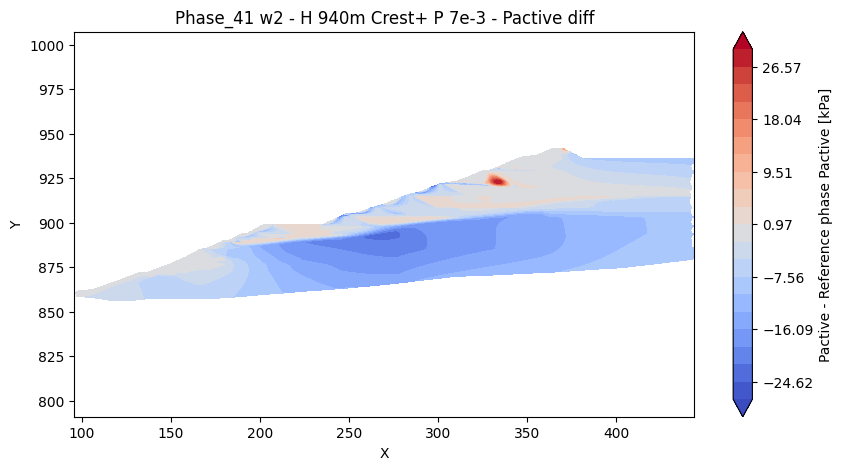

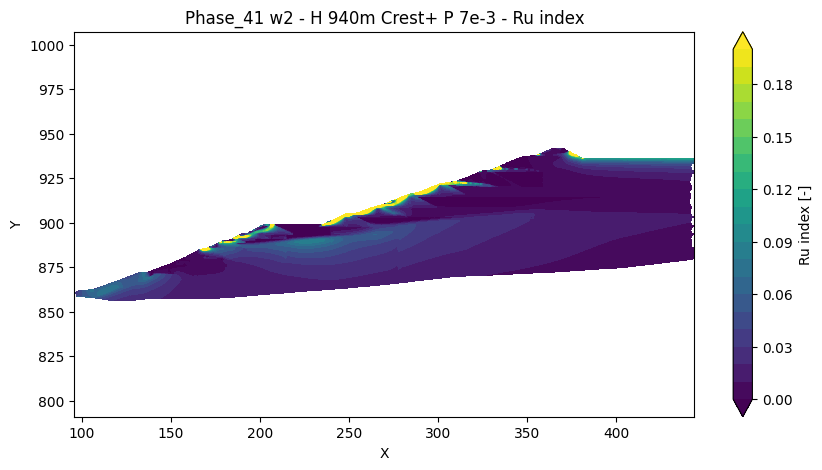

Phase: Phase_41, ID w2 - H 940m Crest+ P 7e-3
  Ru index: 381.0568
domain_area=15089.09, stress_field=SigyyE



In [5]:
# Carpeta principal de figuras (al nivel del notebook)
outdir_figs = os.path.join(os.getcwd(), "figures")
os.makedirs(outdir_figs, exist_ok=True)

results = process_all_phases(dir_raw, config, outdir_figs)